# Uncommon Stimulation Windows: Session 2 vs Session 3
### Identifies trials where stimulation state **differs** between Session 2 and Session 3

**Definition:** A window (trial number) is *not commonly stimulated* if:
- Session 2 has it as **STIM ON** but Session 3 has it as **STIM OFF**, OR
- Session 2 has it as **STIM OFF** but Session 3 has it as **STIM ON**

A window is *commonly stimulated* only if **both** sessions agree on the state.

---
**Prerequisites:** Run the Session 2 and Session 3 pipelines first so that
`trials_s2`, `bslf_rel_s2`, `bslf_mA_s2`, `trials_s3`, `bslf_rel_s3`, `bslf_mA_s3`
are all available in memory, OR use the `load_session` + `classify_trials` helpers below.

## Cell 1 — Imports

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    1.1,
    'figure.dpi':        150,
    'savefig.dpi':       180,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

# ── Color constants ────────────────────────────────────────────────────────
C_ON      = '#1A56DB'   # STIM ON  → blue
C_OFF     = '#90A4AE'   # STIM OFF → grey
C_S2      = '#E65100'   # Session 2 accent (orange)
C_S3      = '#2E7D32'   # Session 3 accent (green)
C_DIFF    = '#D32F2F'   # Discordant (red)
C_AGREE   = '#B0BEC5'   # Concordant (light grey)

print('Imports OK')

Imports OK


## Cell 2 — File Paths (EDIT THESE)

In [2]:
# ── SESSION 2 ─────────────────────────────────────────────────────────────
JSON_PATH_S2   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1433\Report_Json_Session_Report_20260305T151703.json")
CSV_PATH_S2    = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-2-Scores.csv")
EVENTS_PATH_S2 = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\Events.csv")
OUT_DIR_S2     = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2")

# ── SESSION 3 ─────────────────────────────────────────────────────────────
JSON_PATH_S3   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1441\Report_Json_Session_Report_20260305T151912.json")
CSV_PATH_S3    = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-3-Scores.csv")
EVENTS_PATH_S3 = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\Preprocessed Data\Events.csv")
OUT_DIR_S3     = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3")

# ── COMBINED OUTPUT ───────────────────────────────────────────────────────
COMBINED_DIR   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Combined")
COMBINED_DIR.mkdir(parents=True, exist_ok=True)

STIM_THRESHOLD = 2.0   # mA

print('Paths set.')

Paths set.


## Cell 3 — Pipeline Helper Functions
*(Copied from reference notebook — no changes)*

In [3]:
def load_session(json_path, csv_path, events_path, stim_threshold=2.0):
    """
    Full pipeline: load → align → build trials.
    Returns: trials (list of dicts), bslf_rel (np.ndarray), bslf_mA (np.ndarray),
             meta (dict with subject/session/date/offset info)
    """
    with open(json_path) as f:
        report = json.load(f)
    df = pd.read_csv(csv_path,    encoding='utf-8-sig', low_memory=False)
    ev = pd.read_csv(events_path, encoding='utf-8-sig', low_memory=False)

    subject = str(df['Subject'].iloc[0])
    session = str(df['Session'].iloc[0])
    date    = str(df['SessionDate'].iloc[0])

    stim_start_tick = None
    for stream in report['BrainSenseLfp']:
        prev = None
        for pkt in stream['LfpData']:
            curr = pkt['Left']['mA']
            if prev is not None and prev == 0.0 and curr > 0.0:
                stim_start_tick = pkt['TicksInMs']
                break
            prev = curr
        if stim_start_tick is not None:
            break
    assert stim_start_tick, 'ERROR: No 0→>0 mA transition found in BrainSenseLfp!'

    welcome_ms    = int(df['Welcome.TargetOnsetTime'].iloc[0])
    goodbye_ms    = int(df['Goodbye.FinishTime'].iloc[0])
    MANUAL_OFFSET = stim_start_tick - welcome_ms

    def to_rel(eprime_ms):
        return float(eprime_ms) + MANUAL_OFFSET - stim_start_tick

    def tick_to_rel(tick_arr):
        return np.asarray(tick_arr, dtype=float) - stim_start_tick

    bslf_tick, bslf_mA = [], []
    for stream in report['BrainSenseLfp']:
        for pkt in stream['LfpData']:
            bslf_tick.append(pkt['TicksInMs'])
            bslf_mA.append(pkt['Left']['mA'])
    bslf_tick = np.array(bslf_tick, dtype=float)
    bslf_mA   = np.array(bslf_mA,  dtype=float)
    bslf_rel  = tick_to_rel(bslf_tick)

    last_stim_idx   = int(np.where(bslf_mA > 0)[0][-1])
    last_stim_rel   = float(bslf_rel[last_stim_idx])
    session_end_rel = to_rel(goodbye_ms)

    digit_rows = df['Digit'].tolist()
    trial_digit_seqs = {}
    offset = 0
    for tn in range(1, 15):
        t_row = ev[(ev['Event_Type'] == 'Main Trial Start') & (ev['Trial_Number'] == tn)]
        if t_row.empty:
            continue
        n = int(t_row.iloc[0]['Num_Digits'])
        trial_digit_seqs[tn] = digit_rows[offset: offset + n]
        offset += n

    def ev_times_all(etype, trial_num):
        rows = ev[(ev['Event_Type'] == etype) & (ev['Trial_Number'] == trial_num)]
        return [float(x) for x in rows['Time_ms'].tolist()]

    def ev_time_first(etype, trial_num):
        vals = ev_times_all(etype, trial_num)
        return vals[0] if vals else None

    trials = []
    for tn in range(1, 15):
        start_row = ev[(ev['Event_Type'] == 'Main Trial Start') & (ev['Trial_Number'] == tn)]
        if start_row.empty:
            continue
        r = start_row.iloc[0]
        t = {
            'num':       tn,
            'digits':    int(r['Num_Digits']) if pd.notna(r['Num_Digits']) else None,
            'acc':       int(r['ACC'])        if pd.notna(r['ACC'])        else None,
            'cresp':     str(int(r['CRESP'])) if pd.notna(r['CRESP'])      else '?',
            'resp':      str(int(r['RESP']))  if pd.notna(r['RESP'])       else '?',
            'digit_seq': trial_digit_seqs.get(tn, []),
        }
        for key, etype in [('start','Main Trial Start'),('end','Main Trial End'),
                            ('cs','Choice Start'),('ce','Choice End'),
                            ('fb_s','Feedback Start'),('fb_e','Feedback End')]:
            ms = ev_time_first(etype, tn)
            t[key] = to_rel(ms) if ms is not None else None
        t['fix_starts']  = [to_rel(ms) for ms in ev_times_all('Fixation Start',  tn)]
        t['fix_ends']    = [to_rel(ms) for ms in ev_times_all('Fixation End',    tn)]
        t['stim_starts'] = [to_rel(ms) for ms in ev_times_all('Stimulus Start',  tn)]
        t['stim_ends']   = [to_rel(ms) for ms in ev_times_all('Stimulus End',    tn)]
        trials.append(t)

    def mA_at(rel_ms):
        idx = int(np.searchsorted(bslf_rel, rel_ms, side='right')) - 1
        return float(bslf_mA[idx]) if idx >= 0 else 0.0

    for i, t in enumerate(trials):
        t['carryover'] = (mA_at(trials[i+1]['start']) >= stim_threshold
                          if i < len(trials) - 1 else False)

    meta = dict(subject=subject, session=session, date=date,
                manual_offset=MANUAL_OFFSET,
                stim_start_tick=stim_start_tick,
                last_stim_rel=last_stim_rel,
                session_end_rel=session_end_rel,
                mA_max=float(bslf_mA.max()))

    print(f'Loaded {subject} | Session {session} | {date} | '
          f'{len(trials)} trials | mA max={meta["mA_max"]:.1f}')
    return trials, bslf_rel, bslf_mA, meta


# ── Sub-window boundaries ─────────────────────────────────────────────────
# Fixation : fix_starts[0]  → stim_starts[0]   (first digit display)
# Stimulus : stim_starts[0] → stim_ends[-1]     (all digit presentations)
# Choice   : cs             → ce
# Feedback : fb_s           → fb_e
WINDOWS = ['Fixation', 'Stimulus', 'Choice', 'Feedback']


def _window_bounds(t):
    """Return {window_name: (t0, t1)} for the four sub-windows of a trial."""
    bounds = {}
    # Fixation: from first fixation start → first stimulus start (~1 s)
    fix0 = t['fix_starts'][0]  if t['fix_starts']  else None
    stim0 = t['stim_starts'][0] if t['stim_starts'] else None
    bounds['Fixation'] = (fix0, stim0)
    # Stimulus: first stim start → last stim end
    stim_e = t['stim_ends'][-1] if t['stim_ends'] else None
    bounds['Stimulus'] = (stim0, stim_e)
    # Choice
    bounds['Choice']   = (t.get('cs'), t.get('ce'))
    # Feedback
    bounds['Feedback'] = (t.get('fb_s'), t.get('fb_e'))
    return bounds


def _stim_metrics(t0, t1, bslf_rel, bslf_mA, threshold):
    """Compute stim_on/frac/mean_mA for a single [t0, t1] window."""
    if t0 is None or t1 is None or t1 <= t0:
        return dict(stim_on=False, stim_frac=0.0, mean_mA=0.0)
    mask = (bslf_rel >= t0) & (bslf_rel <= t1)
    t_r, t_m = bslf_rel[mask], bslf_mA[mask]
    if len(t_r) < 2:
        mv = float(t_m[0]) if len(t_m) else 0.0
        return dict(stim_on=mv >= threshold, stim_frac=float(mv >= threshold), mean_mA=mv)
    dt       = np.diff(t_r)
    mid_mA   = (t_m[:-1] + t_m[1:]) / 2.0
    total    = t_r[-1] - t_r[0]
    stim_dur = np.sum(dt[mid_mA >= threshold])
    frac     = stim_dur / total if total > 0 else 0.0
    auc      = float(np.trapezoid(t_m, t_r))
    mean_mA  = auc / total if total > 0 else 0.0
    return dict(stim_on=frac >= 0.5, stim_frac=round(frac, 3), mean_mA=round(mean_mA, 3))


def classify_windows(trials, bslf_rel, bslf_mA, threshold=2.0):
    """
    Classify each sub-window (Fixation/Stimulus/Choice/Feedback) per trial.
    Adds t['windows'] = {window_name: {stim_on, stim_frac, mean_mA}}.
    Also keeps whole-trial stim_on for backward-compat.
    """
    for t in trials:
        t['windows'] = {}
        for wname, (t0, t1) in _window_bounds(t).items():
            t['windows'][wname] = _stim_metrics(t0, t1, bslf_rel, bslf_mA, threshold)
        # whole-trial fallback (keep stim_on at trial level)
        t0_full, t1_full = t.get('start'), t.get('end')
        m = _stim_metrics(t0_full, t1_full, bslf_rel, bslf_mA, threshold)
        t.update(stim_on=m['stim_on'], stim_frac=m['stim_frac'], mean_mA=m['mean_mA'])
    return trials


# ── Keep old name as alias so nothing else breaks ─────────────────────────
def classify_trials(trials, bslf_rel, bslf_mA, threshold=2.0):
    return classify_windows(trials, bslf_rel, bslf_mA, threshold)


print('Pipeline helpers defined.')

Pipeline helpers defined.


## Cell 4 — Load & Classify Sessions

In [4]:
# Load
trials_s2, bslf_rel_s2, bslf_mA_s2, meta_s2 = load_session(
    JSON_PATH_S2, CSV_PATH_S2, EVENTS_PATH_S2, STIM_THRESHOLD
)
trials_s3, bslf_rel_s3, bslf_mA_s3, meta_s3 = load_session(
    JSON_PATH_S3, CSV_PATH_S3, EVENTS_PATH_S3, STIM_THRESHOLD
)

# Classify
classify_trials(trials_s2, bslf_rel_s2, bslf_mA_s2, STIM_THRESHOLD)
classify_trials(trials_s3, bslf_rel_s3, bslf_mA_s3, STIM_THRESHOLD)

print('\nBoth sessions loaded and classified.')

Loaded 6 | Session 2 | 03-05-2026 | 14 trials | mA max=4.6
Loaded 6 | Session 3 | 03-05-2026 | 14 trials | mA max=4.7

Both sessions loaded and classified.


## Cell 5 — Build Comparison Table

For every **(trial number × sub-window)** pair present in **both** sessions, record:
- `stim_on_s2` / `stim_on_s3` — stimulation state per window per session
- `stim_frac_s2` / `stim_frac_s3` — fraction of that window that was stimulated
- `mean_mA_s2` / `mean_mA_s3` — mean amplitude during that window
- `acc_s2` / `acc_s3` — trial accuracy (same for all windows of a given trial)
- `agreement` — whether both sessions share the same stimulation state for that window
- `discordance_type` — direction of mismatch

Sub-windows: **Fixation** (fixation start → first stimulus start), **Stimulus** (first → last digit display), **Choice** (cs → ce), **Feedback** (fb_s → fb_e).

In [5]:
# Index trials by trial number for easy lookup
s2_by_num = {t['num']: t for t in trials_s2}
s3_by_num = {t['num']: t for t in trials_s3}

# All trial numbers present in both sessions
common_trials = sorted(set(s2_by_num.keys()) & set(s3_by_num.keys()))

# ── Build ONE row per (trial_num, window) ────────────────────────────────
rows = []
for tn in common_trials:
    t2 = s2_by_num[tn]
    t3 = s3_by_num[tn]
    for wname in WINDOWS:
        w2 = t2.get('windows', {}).get(wname, {})
        w3 = t3.get('windows', {}).get(wname, {})
        on2   = w2.get('stim_on', False)
        on3   = w3.get('stim_on', False)
        agree = (on2 == on3)
        if agree:
            disc_type = 'Both ON' if on2 else 'Both OFF'
        else:
            disc_type = 'S2 ON / S3 OFF' if on2 else 'S2 OFF / S3 ON'
        rows.append(dict(
            trial_num        = tn,
            window           = wname,
            stim_on_s2       = on2,
            stim_on_s3       = on3,
            stim_frac_s2     = w2.get('stim_frac', 0.0),
            stim_frac_s3     = w3.get('stim_frac', 0.0),
            mean_mA_s2       = w2.get('mean_mA', 0.0),
            mean_mA_s3       = w3.get('mean_mA', 0.0),
            acc_s2           = t2.get('acc'),
            acc_s3           = t3.get('acc'),
            digits_s2        = t2.get('digits'),
            agreement        = agree,
            discordance_type = disc_type,
        ))

df_compare = pd.DataFrame(rows)

n_total_windows = len(df_compare)
print(f'Total (trial × window) pairs : {n_total_windows}')
print(f'Concordant (same state)       : {df_compare["agreement"].sum()}')
print(f'Discordant (diff state)       : {(~df_compare["agreement"]).sum()}')
print()
print(df_compare[['trial_num','window','stim_on_s2','stim_on_s3',
                   'stim_frac_s2','stim_frac_s3','agreement','discordance_type']].to_string(index=False))

Total (trial × window) pairs : 56
Concordant (same state)       : 26
Discordant (diff state)       : 30

 trial_num   window  stim_on_s2  stim_on_s3  stim_frac_s2  stim_frac_s3  agreement discordance_type
         1 Fixation       False       False         0.000         0.000       True         Both OFF
         1 Stimulus       False       False         0.000         0.000       True         Both OFF
         1   Choice       False       False         0.000         0.000       True         Both OFF
         1 Feedback       False       False         0.000         0.000       True         Both OFF
         2 Fixation       False       False         0.000         0.000       True         Both OFF
         2 Stimulus       False       False         0.000         0.000       True         Both OFF
         2   Choice       False       False         0.000         0.000       True         Both OFF
         2 Feedback       False       False         0.000         0.000       True         Both

## Cell 6 — Isolate Discordant (Uncommon) Windows

In [6]:
df_uncommon  = df_compare[~df_compare['agreement']].reset_index(drop=True)
df_concordant = df_compare[df_compare['agreement']].reset_index(drop=True)

print('=' * 65)
print('  WINDOWS NOT COMMONLY STIMULATED (discordant between S2 & S3)')
print('=' * 65)

if df_uncommon.empty:
    print('  ✓ All trial windows share the same stimulation state across sessions.')
else:
    print(f'  {len(df_uncommon)} discordant trial(s) found:\n')
    display_cols = [
        'trial_num', 'window', 'discordance_type',
        'stim_frac_s2', 'stim_frac_s3',
        'mean_mA_s2',   'mean_mA_s3',
        'acc_s2',       'acc_s3',
    ]
    print(df_uncommon[display_cols].to_string(index=False))

print()
print('Discordance breakdown by window:')
print(df_compare.groupby('window')['discordance_type'].value_counts().to_string())

  WINDOWS NOT COMMONLY STIMULATED (discordant between S2 & S3)
  30 discordant trial(s) found:

 trial_num   window discordance_type  stim_frac_s2  stim_frac_s3  mean_mA_s2  mean_mA_s3  acc_s2  acc_s3
         3 Fixation   S2 OFF / S3 ON           0.0         1.000       1.900       4.500       1       1
         3 Stimulus   S2 OFF / S3 ON           0.4         0.778       1.960       3.350       1       1
         4 Stimulus   S2 OFF / S3 ON           0.0         0.778       0.056       3.050       1       0
         6 Feedback   S2 OFF / S3 ON           0.0         1.000       0.000       4.425       0       1
         7 Fixation   S2 OFF / S3 ON           0.0         1.000       1.900       4.500       0       0
         7   Choice   S2 ON / S3 OFF           1.0         0.000       2.225       0.138       0       0
         7 Feedback   S2 ON / S3 OFF           1.0         0.000       3.025       0.175       0       0
         8 Fixation   S2 ON / S3 OFF           1.0         0.000

## Cell 7 — Full Comparison Table (display)

In [7]:
# Styled table: highlight discordant rows in red, concordant in grey/blue
def highlight_row(row):
    if not row['agreement']:
        return ['background-color: #FFEBEE; color: #B71C1C'] * len(row)
    elif row['discordance_type'] == 'Both ON':
        return ['background-color: #E3F2FD; color: #0D47A1'] * len(row)
    else:
        return ['background-color: #F5F5F5; color: #424242'] * len(row)

display_cols = [
    'trial_num', 'window', 'discordance_type',
    'stim_on_s2', 'stim_on_s3',
    'stim_frac_s2', 'stim_frac_s3',
    'mean_mA_s2', 'mean_mA_s3',
    'acc_s2', 'acc_s3',
    'agreement',
]

styled = (
    df_compare[display_cols]
    .style
    .apply(highlight_row, axis=1)
    .set_caption('Trial-by-Trial Stimulation State Comparison (Red = Discordant)')
    .format({
        'stim_frac_s2': '{:.3f}', 'stim_frac_s3': '{:.3f}',
        'mean_mA_s2':   '{:.3f}', 'mean_mA_s3':   '{:.3f}',
    })
)
display(styled)

,trial_num,window,discordance_type,stim_on_s2,stim_on_s3,stim_frac_s2,stim_frac_s3,mean_mA_s2,mean_mA_s3,acc_s2,acc_s3,agreement
0,1,Fixation,Both OFF,False,False,0.000,0.000,1.100,0.100,1,1,True
1,1,Stimulus,Both OFF,False,False,0.000,0.000,0.970,0.030,1,1,True
2,1,Choice,Both OFF,False,False,0.000,0.000,0.850,0.050,1,1,True
3,1,Feedback,Both OFF,False,False,0.000,0.000,0.825,0.025,1,1,True
4,2,Fixation,Both OFF,False,False,0.000,0.000,0.900,0.100,1,1,True
5,2,Stimulus,Both OFF,False,False,0.000,0.000,1.000,0.033,1,1,True
6,2,Choice,Both OFF,False,False,0.000,0.000,1.100,0.100,1,1,True
7,2,Feedback,Both OFF,False,False,0.000,0.000,1.200,0.200,1,1,True
8,3,Fixation,S2 OFF / S3 ON,False,True,0.000,1.000,1.900,4.500,1,1,False
9,3,Stimulus,S2 OFF / S3 ON,False,True,0.400,0.778,1.960,3.350,1,1,False


## Cell 8 — Plot: Stimulation Fraction per Trial (S2 vs S3)
Bars show `stim_frac` for each session. The dashed red line is the 0.5 threshold.
Discordant trials are highlighted in red.

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Combined\uncommon_stim_windows_stim_frac.png


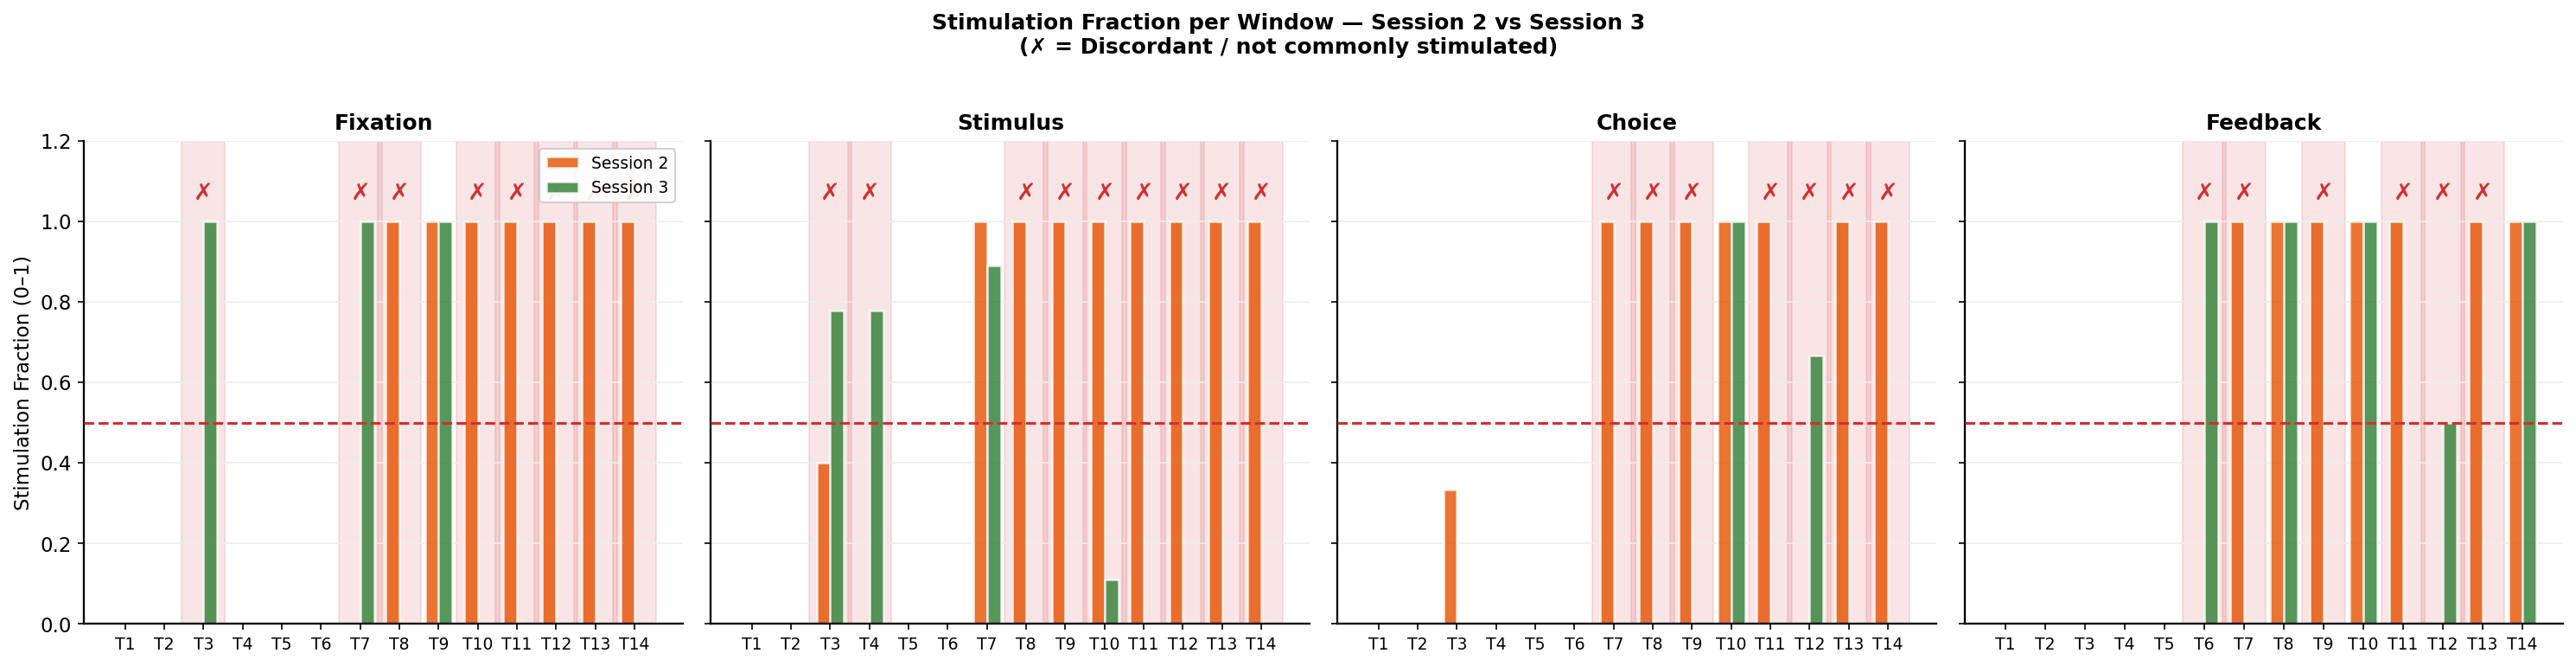

In [8]:
# ── One subplot per window ───────────────────────────────────────────────
fig, axes = plt.subplots(1, len(WINDOWS), figsize=(5 * len(WINDOWS), 5), sharey=True)

for ax, wname in zip(axes, WINDOWS):
    wdf = df_compare[df_compare['window'] == wname].reset_index(drop=True)
    trial_nums = wdf['trial_num'].values
    x  = np.arange(len(trial_nums))
    bw = 0.35

    ax.bar(x - bw/2, wdf['stim_frac_s2'], width=bw,
           color=C_S2, alpha=0.80, label='Session 2', edgecolor='white', lw=1.2)
    ax.bar(x + bw/2, wdf['stim_frac_s3'], width=bw,
           color=C_S3, alpha=0.80, label='Session 3', edgecolor='white', lw=1.2)

    # Highlight discordant trials
    for i, (_, row) in enumerate(wdf.iterrows()):
        if not row['agreement']:
            ax.axvspan(i - 0.55, i + 0.55, color=C_DIFF, alpha=0.12, zorder=0)
            ax.text(i, 1.04, '✗', ha='center', va='bottom',
                    fontsize=13, color=C_DIFF, fontweight='bold')

    ax.axhline(0.5, color=C_DIFF, lw=1.5, ls='--', zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels([f'T{tn}' for tn in trial_nums], fontsize=9)
    ax.set_title(wname, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.20)
    ax.yaxis.grid(True, color='#eee', lw=0.8); ax.set_axisbelow(True)
    if ax is axes[0]:
        ax.set_ylabel('Stimulation Fraction (0–1)', fontsize=11)
        ax.legend(fontsize=9, framealpha=0.9, edgecolor='#ccc', loc='upper right')

fig.suptitle('Stimulation Fraction per Window — Session 2 vs Session 3\n'
             '(✗ = Discordant / not commonly stimulated)',
             fontsize=12, fontweight='bold', y=1.02)
fig.tight_layout()
out_path = COMBINED_DIR / 'uncommon_stim_windows_stim_frac.png'
fig.savefig(out_path, bbox_inches='tight')
print(f'Saved → {out_path}')
plt.show()
plt.close(fig)

## Cell 9 — Plot: Agreement Heatmap
Visual grid showing stimulation state for each (trial, session) cell.
Discordant pairs are bordered in red.

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Combined\uncommon_stim_windows_heatmap.png


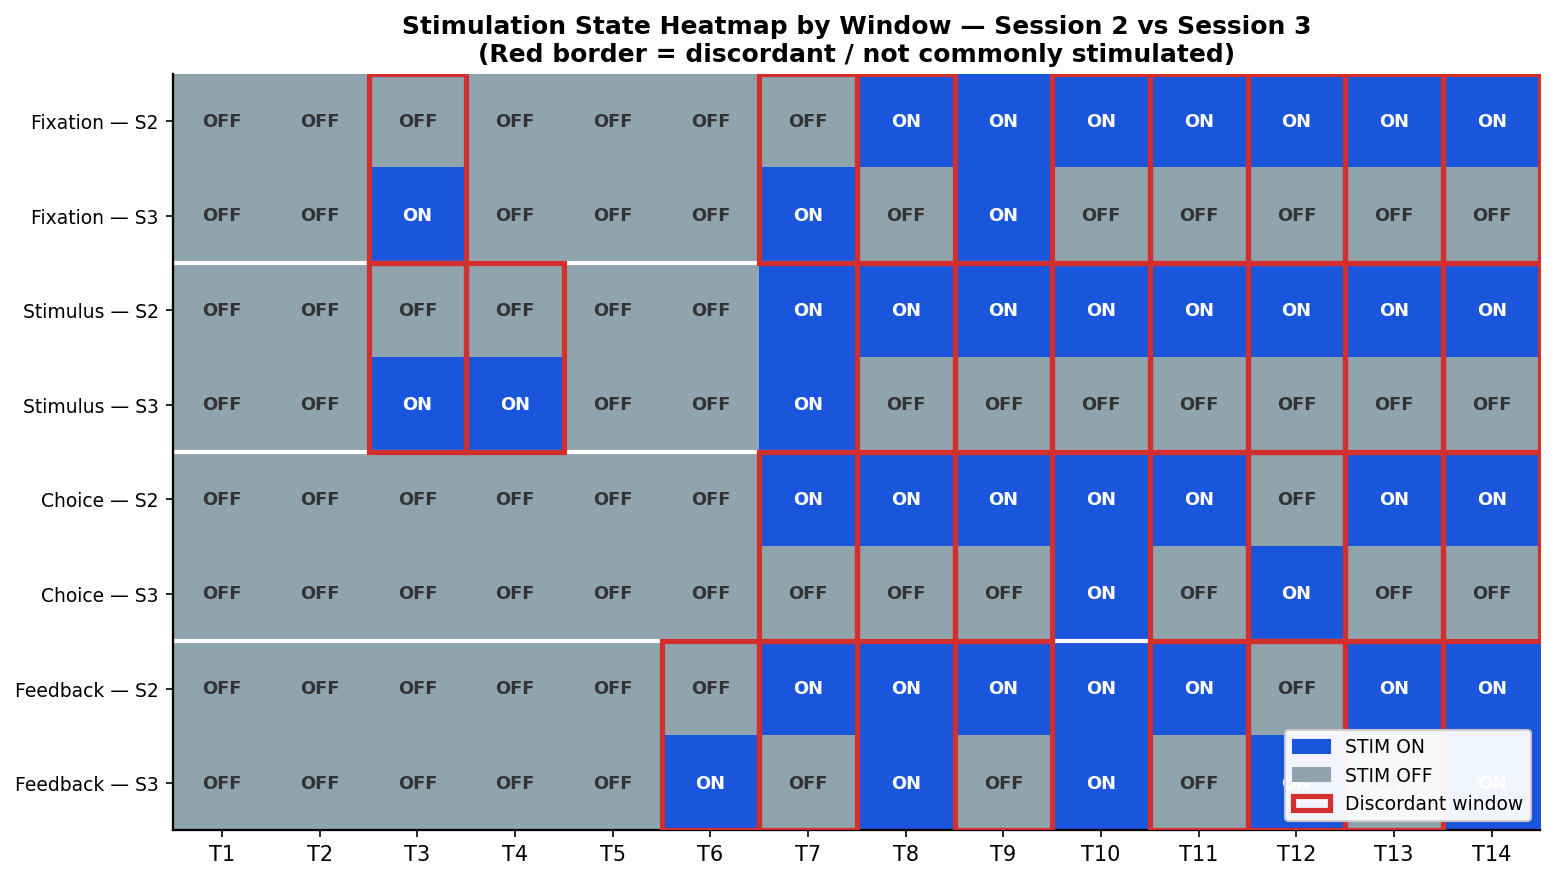

In [9]:
from matplotlib.colors import ListedColormap
cmap = ListedColormap([C_OFF, C_ON])

# Pivot: rows = windows, cols = trial numbers, two sub-rows per window (S2/S3)
# Layout: 4 windows × 2 sessions = 8 rows
trial_nums = sorted(df_compare['trial_num'].unique())
n_trials   = len(trial_nums)
tn_to_col  = {tn: i for i, tn in enumerate(trial_nums)}

grid = np.zeros((len(WINDOWS) * 2, n_trials))  # 8 × n_trials
for _, row in df_compare.iterrows():
    wi  = WINDOWS.index(row['window'])
    col = tn_to_col[row['trial_num']]
    grid[wi * 2,     col] = int(row['stim_on_s2'])
    grid[wi * 2 + 1, col] = int(row['stim_on_s3'])

fig, ax = plt.subplots(figsize=(max(10, n_trials * 0.75), 6))
ax.imshow(grid, cmap=cmap, vmin=0, vmax=1, aspect='auto')

# Annotate cells
for r in range(grid.shape[0]):
    for c in range(grid.shape[1]):
        val   = 'ON' if grid[r, c] else 'OFF'
        color = 'white' if grid[r, c] else '#333'
        ax.text(c, r, val, ha='center', va='center',
                fontsize=8.5, fontweight='bold', color=color)

# Red borders on discordant (trial, window) pairs
for _, row in df_compare.iterrows():
    if not row['agreement']:
        wi  = WINDOWS.index(row['window'])
        col = tn_to_col[row['trial_num']]
        rect = plt.Rectangle((col - 0.5, wi * 2 - 0.5), 1, 2,
                              linewidth=2.5, edgecolor=C_DIFF,
                              facecolor='none', zorder=5)
        ax.add_patch(rect)

# Y-axis: label each pair of rows as 'WindowName S2 / S3'
ytick_pos    = [wi * 2 + 0.5 for wi in range(len(WINDOWS))]
ytick_labels = [f'{w}\nS2 / S3' for w in WINDOWS]
ax.set_yticks([wi * 2 for wi in range(len(WINDOWS))] +
              [wi * 2 + 1 for wi in range(len(WINDOWS))])
ax.set_yticklabels(
    [f'{w} — S2' for w in WINDOWS] + [f'{w} — S3' for w in WINDOWS],
    fontsize=9
)
# Re-sort y-tick labels in row order
ax.set_yticks(range(len(WINDOWS) * 2))
ax.set_yticklabels(
    [f'{WINDOWS[r // 2]} — {"S2" if r % 2 == 0 else "S3"}' for r in range(len(WINDOWS) * 2)],
    fontsize=9
)

ax.set_xticks(range(n_trials))
ax.set_xticklabels([f'T{tn}' for tn in trial_nums], fontsize=10)
ax.set_title('Stimulation State Heatmap by Window — Session 2 vs Session 3\n'
             '(Red border = discordant / not commonly stimulated)',
             fontsize=12, fontweight='bold')

# Horizontal separators between windows
for wi in range(1, len(WINDOWS)):
    ax.axhline(wi * 2 - 0.5, color='white', lw=2)

handles = [
    mpatches.Patch(color=C_ON,  label='STIM ON'),
    mpatches.Patch(color=C_OFF, label='STIM OFF'),
    mpatches.Patch(edgecolor=C_DIFF, facecolor='none',
                   linewidth=2.5, label='Discordant window'),
]
ax.legend(handles=handles, fontsize=9, loc='lower right',
          framealpha=0.95, edgecolor='#ccc')

fig.tight_layout()
out_path = COMBINED_DIR / 'uncommon_stim_windows_heatmap.png'
fig.savefig(out_path, bbox_inches='tight')
print(f'Saved → {out_path}')
plt.show()
plt.close(fig)

## Cell 10 — Plot: Accuracy on Discordant vs Concordant Windows

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Combined\uncommon_stim_windows_accuracy.png


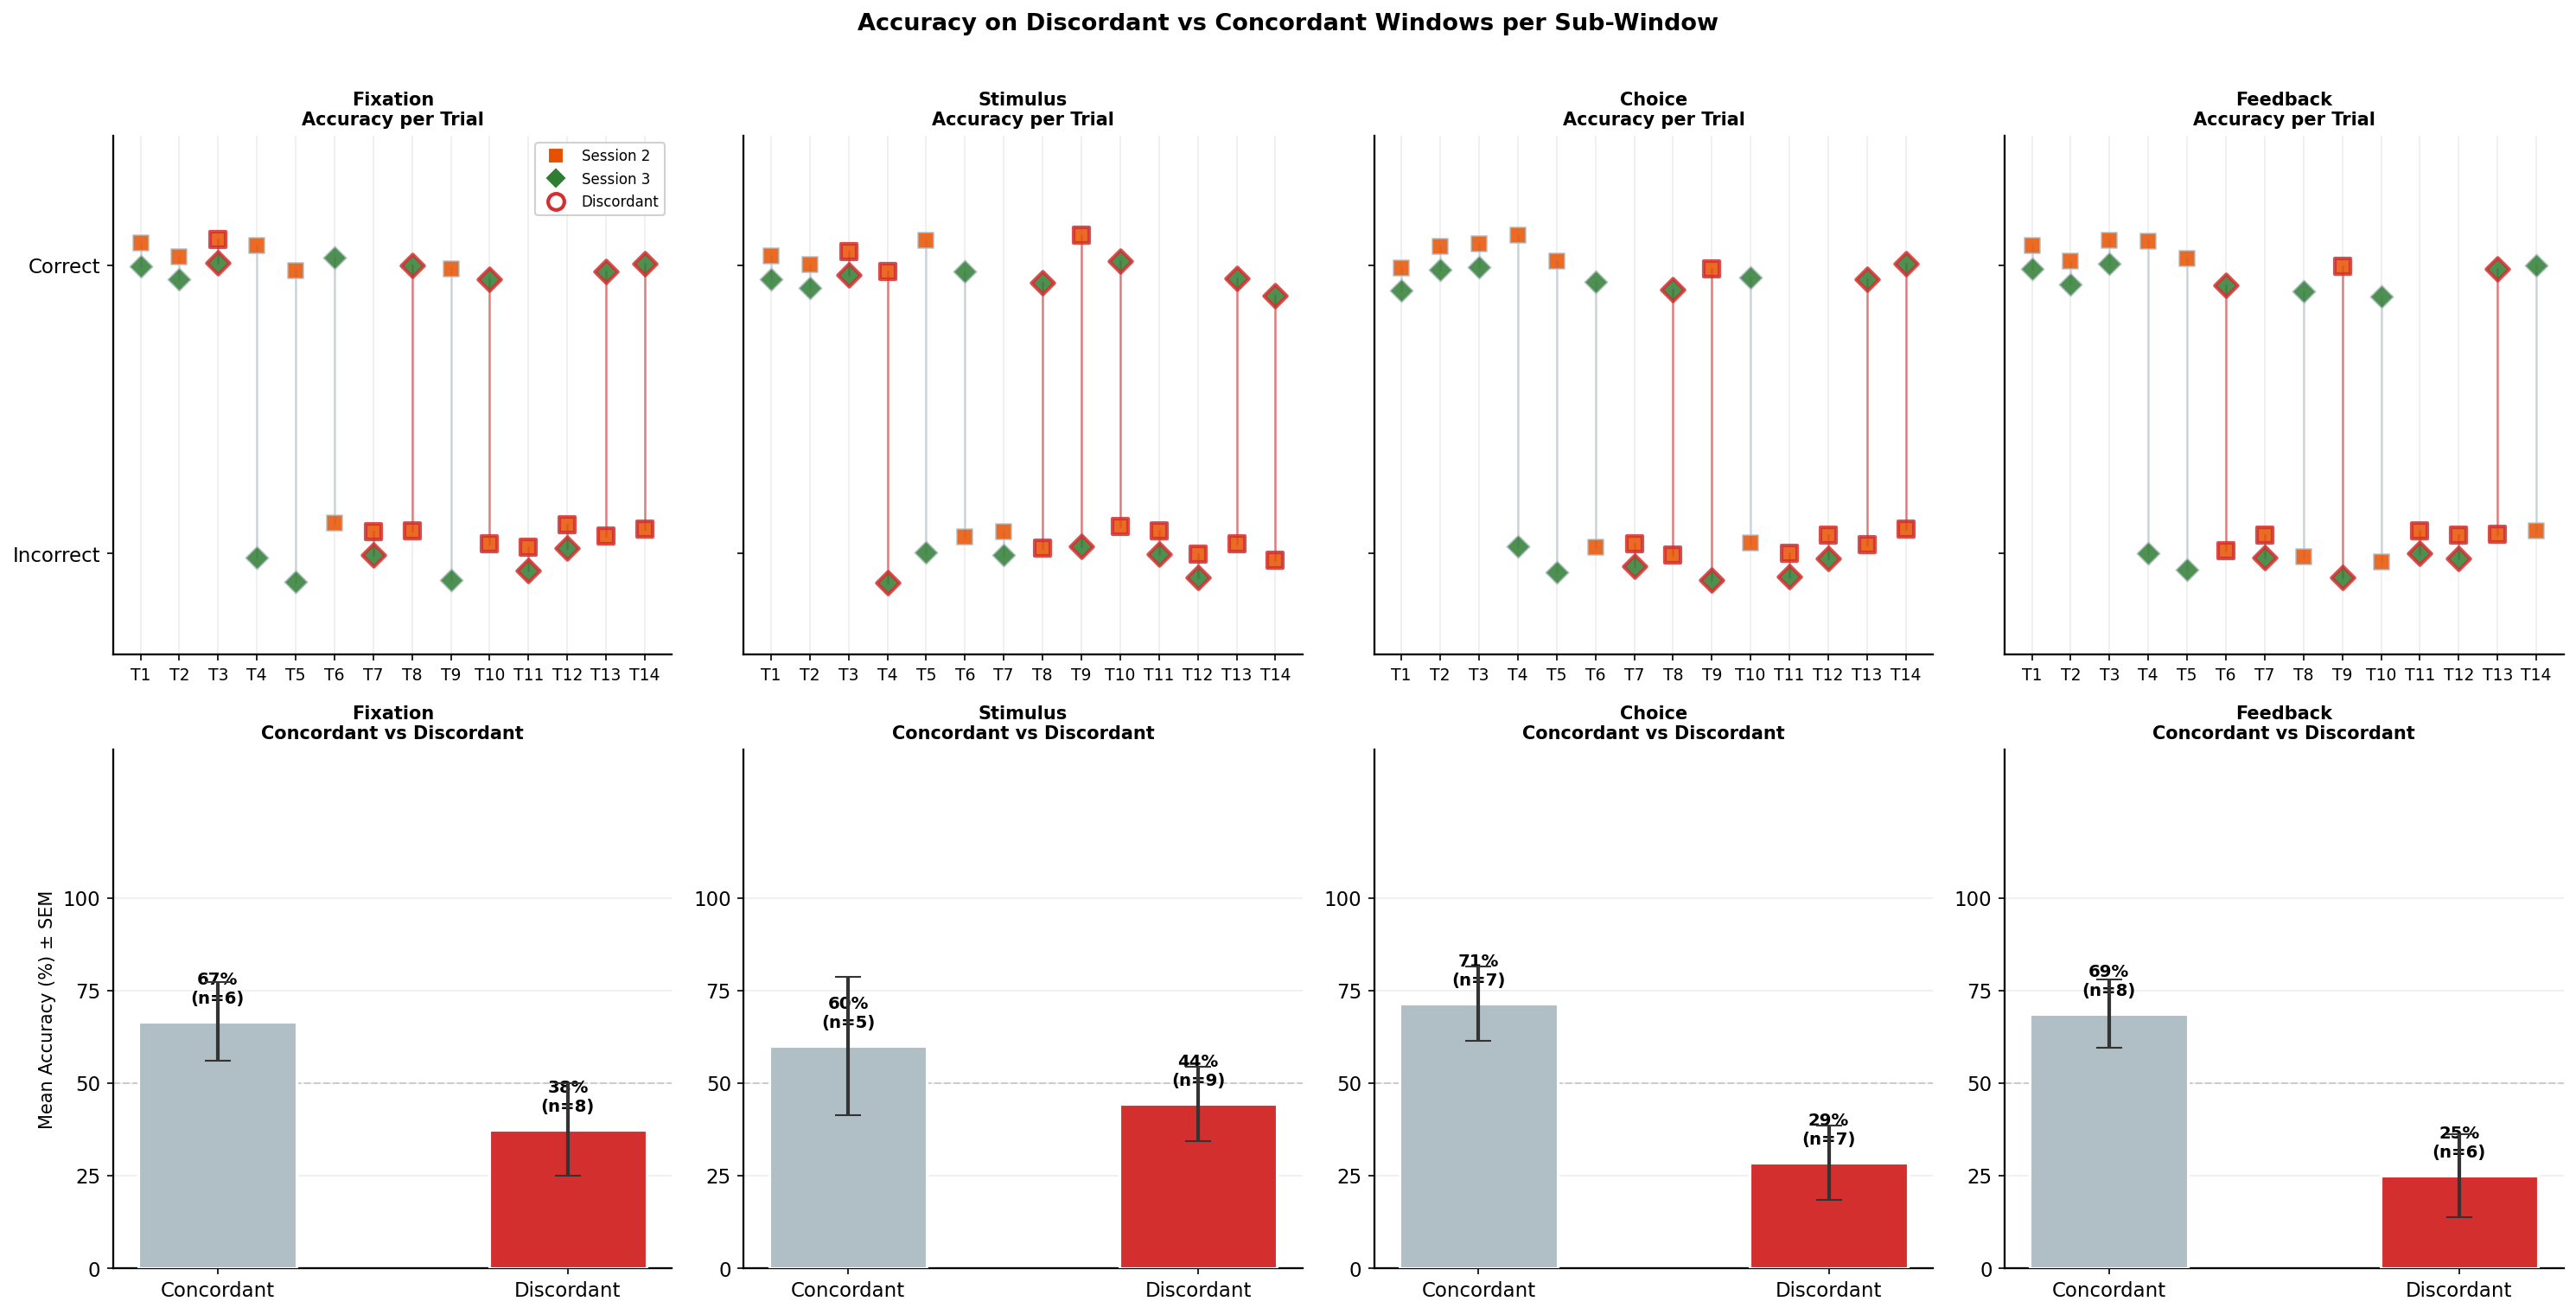

In [10]:
df_compare['mean_acc'] = df_compare[['acc_s2', 'acc_s3']].mean(axis=1)
rng = np.random.default_rng(42)

fig, axes = plt.subplots(2, len(WINDOWS), figsize=(5 * len(WINDOWS), 10))

for wi, wname in enumerate(WINDOWS):
    wdf = df_compare[df_compare['window'] == wname].reset_index(drop=True)

    # ── Row 0: per-trial accuracy scatter ────────────────────────────────
    ax = axes[0, wi]
    for _, row in wdf.iterrows():
        color  = C_DIFF if not row['agreement'] else C_AGREE
        zorder = 5 if not row['agreement'] else 3
        jit    = rng.uniform(-0.07, 0.07)
        ax.scatter(row['trial_num'], row['acc_s2'] + jit + 0.04,
                   marker='s', c=C_S2, s=80, alpha=0.85,
                   edgecolors=color, linewidths=2.0 if not row['agreement'] else 0.8,
                   zorder=zorder)
        ax.scatter(row['trial_num'], row['acc_s3'] + jit - 0.04,
                   marker='D', c=C_S3, s=80, alpha=0.85,
                   edgecolors=color, linewidths=2.0 if not row['agreement'] else 0.8,
                   zorder=zorder)
        ax.plot([row['trial_num'], row['trial_num']],
                [row['acc_s2'] + jit + 0.04, row['acc_s3'] + jit - 0.04],
                color=color, lw=1.2, alpha=0.6, zorder=zorder - 1)
    ax.set_xlim(wdf['trial_num'].min() - 0.7, wdf['trial_num'].max() + 0.7)
    ax.set_ylim(-0.35, 1.45)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Incorrect', 'Correct'] if wi == 0 else ['', ''])
    ax.set_xticks(wdf['trial_num'].values)
    ax.set_xticklabels([f'T{tn}' for tn in wdf['trial_num'].values], fontsize=9)
    ax.set_title(f'{wname}\nAccuracy per Trial', fontsize=10, fontweight='bold')
    ax.grid(True, axis='x', color='#eee', lw=0.8)
    if wi == 0:
        handles_scatter = [
            Line2D([0],[0], marker='s', color='w', markerfacecolor=C_S2,
                   markersize=9, label='Session 2'),
            Line2D([0],[0], marker='D', color='w', markerfacecolor=C_S3,
                   markersize=9, label='Session 3'),
            Line2D([0],[0], marker='o', color='w', markerfacecolor='w',
                   markeredgecolor=C_DIFF, markeredgewidth=2, markersize=9,
                   label='Discordant'),
        ]
        ax.legend(handles=handles_scatter, fontsize=8, framealpha=0.9)

    # ── Row 1: mean accuracy concordant vs discordant ─────────────────────
    ax2 = axes[1, wi]
    g_conc = wdf[wdf['agreement']]['mean_acc'].dropna()
    g_disc = wdf[~wdf['agreement']]['mean_acc'].dropna()
    means  = [g_conc.mean() if len(g_conc) else np.nan,
              g_disc.mean() if len(g_disc) else np.nan]
    sems   = [g_conc.sem()  if len(g_conc) > 1 else 0,
              g_disc.sem()  if len(g_disc) > 1 else 0]
    groups = ['Concordant', 'Discordant']
    colors = [C_AGREE, C_DIFF]
    valid  = [(g, m, s, c) for g, m, s, c in zip(groups, means, sems, colors)
              if not np.isnan(m)]
    if valid:
        g_v, m_v, s_v, c_v = zip(*valid)
        ax2.bar(g_v, [m*100 for m in m_v], color=c_v,
                width=0.45, edgecolor='white', lw=1.5, zorder=3)
        ax2.errorbar(list(range(len(g_v))), [m*100 for m in m_v],
                     yerr=[s*100 for s in s_v],
                     fmt='none', color='#333', capsize=7, lw=2, zorder=4)
        ns = [len(g_conc), len(g_disc)]
        for i_b, (m, n_cnt) in enumerate(zip(m_v, ns[:len(m_v)])):
            ax2.text(i_b, m*100 + 4, f'{m*100:.0f}%\n(n={n_cnt})',
                     ha='center', va='bottom', fontsize=9.5, fontweight='bold')
    ax2.set_ylim(0, 140)
    ax2.set_yticks([0, 25, 50, 75, 100])
    if wi == 0:
        ax2.set_ylabel('Mean Accuracy (%) ± SEM', fontsize=10)
    ax2.set_title(f'{wname}\nConcordant vs Discordant', fontsize=10, fontweight='bold')
    ax2.axhline(50, color='#ccc', lw=1, ls='--', zorder=1)
    ax2.yaxis.grid(True, color='#eee', zorder=0); ax2.set_axisbelow(True)

fig.suptitle('Accuracy on Discordant vs Concordant Windows per Sub-Window',
             fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
out_path = COMBINED_DIR / 'uncommon_stim_windows_accuracy.png'
fig.savefig(out_path, bbox_inches='tight')
print(f'Saved → {out_path}')
plt.show()
plt.close(fig)

## Cell 11 — Summary Table

In [11]:
# ── Overall counts ────────────────────────────────────────────────────────
n_total       = len(df_compare)
n_concordant  = df_compare['agreement'].sum()
n_discordant  = (~df_compare['agreement']).sum()
n_both_on     = (df_compare['discordance_type'] == 'Both ON').sum()
n_both_off    = (df_compare['discordance_type'] == 'Both OFF').sum()
n_s2on_s3off  = (df_compare['discordance_type'] == 'S2 ON / S3 OFF').sum()
n_s2off_s3on  = (df_compare['discordance_type'] == 'S2 OFF / S3 ON').sum()

summary_rows = [
    dict(Category='Total (trial × window) pairs',           Count=n_total,      Pct='100%'),
    dict(Category='Concordant (same state both sessions)',   Count=n_concordant, Pct=f'{n_concordant/n_total*100:.1f}%'),
    dict(Category='  → Both STIM ON',                       Count=n_both_on,    Pct=f'{n_both_on/n_total*100:.1f}%'),
    dict(Category='  → Both STIM OFF',                      Count=n_both_off,   Pct=f'{n_both_off/n_total*100:.1f}%'),
    dict(Category='Discordant (NOT commonly stimulated)',    Count=n_discordant, Pct=f'{n_discordant/n_total*100:.1f}%'),
    dict(Category='  → S2 ON / S3 OFF',                     Count=n_s2on_s3off, Pct=f'{n_s2on_s3off/n_total*100:.1f}%'),
    dict(Category='  → S2 OFF / S3 ON',                     Count=n_s2off_s3on, Pct=f'{n_s2off_s3on/n_total*100:.1f}%'),
]

df_summary = pd.DataFrame(summary_rows)

print('\n' + '='*65)
print('  UNCOMMON STIMULATION WINDOWS — SUMMARY (per sub-window)')
print('='*65)
print(df_summary.to_string(index=False))

# Per-window breakdown
print('\n--- Discordant counts per sub-window ---')
wsum = (df_compare.groupby('window')['agreement']
        .apply(lambda x: (~x).sum()).rename('n_discordant'))
wtot = df_compare.groupby('window').size().rename('n_total')
wdf_sum = pd.concat([wtot, wsum], axis=1)
wdf_sum['pct_discordant'] = (wdf_sum['n_discordant'] / wdf_sum['n_total'] * 100).round(1)
wdf_sum = wdf_sum.reindex(WINDOWS)
print(wdf_sum.to_string())

if n_discordant > 0:
    disc_rows = df_uncommon[['trial_num','window']].apply(
        lambda r: f'T{r["trial_num"]} ({r["window"]})', axis=1
    ).tolist()
    print(f'\nDiscordant pairs: ' + ', '.join(disc_rows))
else:
    print('\nNo discordant windows — all (trial, window) pairs are commonly stimulated.')

print()
display(df_summary.style.set_caption('Stimulation Window Agreement — Session 2 vs Session 3'))


  UNCOMMON STIMULATION WINDOWS — SUMMARY (per sub-window)
                             Category  Count   Pct
         Total (trial × window) pairs     56  100%
Concordant (same state both sessions)     26 46.4%
                       → Both STIM ON      6 10.7%
                      → Both STIM OFF     20 35.7%
 Discordant (NOT commonly stimulated)     30 53.6%
                     → S2 ON / S3 OFF     23 41.1%
                     → S2 OFF / S3 ON      7 12.5%

--- Discordant counts per sub-window ---
          n_total  n_discordant  pct_discordant
window                                         
Fixation       14             8            57.1
Stimulus       14             9            64.3
Choice         14             7            50.0
Feedback       14             6            42.9

Discordant pairs: T3 (Fixation), T3 (Stimulus), T4 (Stimulus), T6 (Feedback), T7 (Fixation), T7 (Choice), T7 (Feedback), T8 (Fixation), T8 (Stimulus), T8 (Choice), T9 (Stimulus), T9 (Choice), T9 (Feedba

,Category,Count,Pct
0,Total (trial × window) pairs,56,100%
1,Concordant (same state both sessions),26,46.4%
2,→ Both STIM ON,6,10.7%
3,→ Both STIM OFF,20,35.7%
4,Discordant (NOT commonly stimulated),30,53.6%
5,→ S2 ON / S3 OFF,23,41.1%
6,→ S2 OFF / S3 ON,7,12.5%


## Cell 12 — Export Results to CSV

In [12]:
# Full comparison
out_full = COMBINED_DIR / 'stim_window_comparison_s2_vs_s3.csv'
df_compare.to_csv(out_full, index=False)
print(f'Full comparison saved → {out_full}')

# Discordant only
if not df_uncommon.empty:
    out_disc = COMBINED_DIR / 'discordant_stim_windows_s2_vs_s3.csv'
    df_uncommon.to_csv(out_disc, index=False)
    print(f'Discordant windows saved → {out_disc}')
else:
    print('No discordant windows to export.')

Full comparison saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Combined\stim_window_comparison_s2_vs_s3.csv
Discordant windows saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Combined\discordant_stim_windows_s2_vs_s3.csv
